In [ ]:
# Uploading the dataset into Google Colab environment
from google.colab import files
uploaded = files.upload()

TypeError: 'NoneType' object is not subscriptable

In [ ]:
# Importing required libaries
import pandas as pd          # For data maniuplation
import numpy as np           # For numerical operations
import matplotlib.pyplot as plt     # For plotting graphs
import seaborn as sns        # for advanced visalizations


In [ ]:
# loading dataset and correcting header row
# header = 1 is used because the first row does not contain actual column names
df = pd.read_excel('Sales Data_PDA_4052.xlsx', header = 1)

# Displaying first few rows to understand structure
df.head()


,order_id,customer_id,sales_person,priority,ship_mode,date,value_£
0,8999,C406,Kelly,High,Plane,2020-06-12,1553.44
1,47872,C100,Kelly,Critical,Plane,2020-06-12,315.40
2,29988,C006,Kelly,High,Lorry,2020-06-12,5075.89
3,37348,C492,Kelly,High,Plane,2020-06-13,520.67
4,28001,C231,Kelly,Critical,Plane,2020-06-14,8431.37


In [ ]:
# Checking dataset structure, data types, and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      1001 non-null   int64         
 1   customer_id   1001 non-null   object        
 2   sales_person  1001 non-null   object        
 3   priority      1001 non-null   object        
 4   ship_mode     1001 non-null   object        
 5   date          1001 non-null   datetime64[ns]
 6   value_£       1001 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 54.9+ KB


In [ ]:
# Generating summary statistics for numerical variables
df.describe()

,order_id,date,value_£
count,1001.000000,1001,1001.000000
mean,30231.488511,2020-09-04 08:03:21.398601216,1778.402248
min,224.000000,2020-06-12 00:00:00,2.450000
25%,16451.000000,2020-07-26 00:00:00,134.400000
50%,29667.000000,2020-09-04 00:00:00,417.580000
75%,44583.000000,2020-10-15 00:00:00,1816.930000
max,59591.000000,2020-11-30 00:00:00,27448.240000
std,16744.674540,NaN,3457.457206


In [ ]:
# Checking for missing values in each column
df.isnull().sum()

,0
order_id,0
customer_id,0
sales_person,0
priority,0
ship_mode,0
date,0
value_£,0


In [ ]:
# Checking for duplicate records in the dataset
df.duplicated().sum()

np.int64(0)

In [ ]:
# Checking all unique priority categories in the dataset
df['priority'].unique()

array(['High', 'Critical', 'Not Specified', 'Low', 'Medium'], dtype=object)

In [ ]:
# Data Cleaning
# Removing extra spaces from text columns to ensure consitency
df ['sales_person'] = df['sales_person'].str.strip()
df['priority'] = df['priority'].str.strip()
df['ship_mode'] = df['ship_mode'].str.strip()

In [ ]:
df.head()

,order_id,customer_id,sales_person,priority,ship_mode,date,value_£
0,8999,C406,Kelly,High,Plane,2020-06-12,1553.44
1,47872,C100,Kelly,Critical,Plane,2020-06-12,315.40
2,29988,C006,Kelly,High,Lorry,2020-06-12,5075.89
3,37348,C492,Kelly,High,Plane,2020-06-13,520.67
4,28001,C231,Kelly,Critical,Plane,2020-06-14,8431.37


In [ ]:
# Grouping data by salesperson and calculating total sales
sales_by_person = df.groupby('sales_person')['value_£'].sum()

# Sorting results to identify top-performing salespersons
sales_by_person = sales_by_person.sort_values(ascending=False)

# Displaying results
sales_by_person

,value_£
sales_person,
Pryia,672228.97
Kelly,558659.62
Peter,549292.06


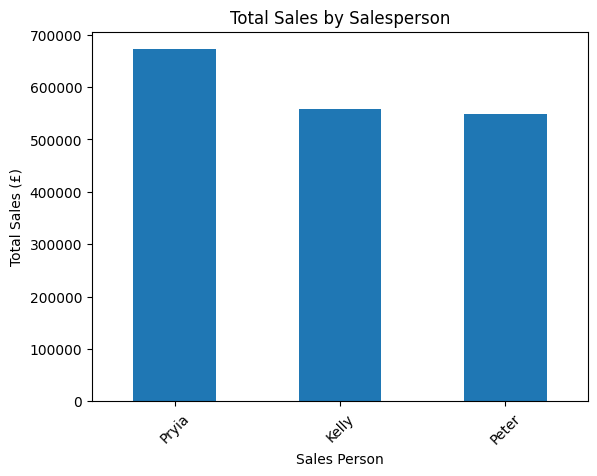

In [ ]:
# Creating a bar chart to compare salesperson performance
sales_by_person.plot(kind='bar')

plt.title('Total Sales by Salesperson')
plt.xlabel('Sales Person')
plt.ylabel('Total Sales (£)')
plt.xticks(rotation=45)

plt.show()

In [ ]:
# Checking unique values in priority column to identify inconsistencies
df['priority'].unique()

array(['High', 'Critical', 'Not Specified', 'Low', 'Medium'], dtype=object)

In [ ]:
# Removing rows where priority is 'Not Specified' as it is not a valid category
df_clean = df[df['priority'] != 'Not Specified'].copy()
df_clean['priority'].unique()

array(['High', 'Critical', 'Low', 'Medium'], dtype=object)

In [ ]:
# Calculating total sales for each priority level
priority_sales = df_clean.groupby('priority')['value_£'].sum()

# Sorting priority levels by total sales
priority_sales = priority_sales.sort_values(ascending=False)

priority_sales

,value_£
priority,
Critical,403652.33
High,381543.40
Medium,330337.37
Low,292535.81


In [ ]:
# Converting priority categories into numerical codes for correlation analysis
df_clean['priority_code'] = df_clean['priority'].astype('category').cat.codes
df_clean[['priority_code','value_£']].corr()

,priority_code,value_£
priority_code,1.000000,-0.008096
value_£,-0.008096,1.000000


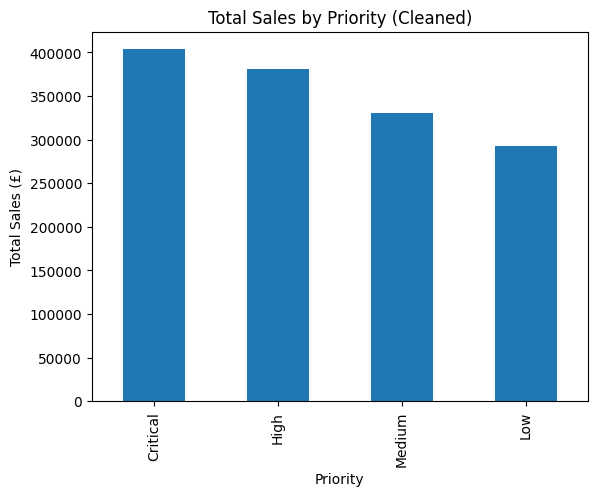

In [ ]:
# Visualising sales distribution across priority
priority_sales.plot(kind='bar')

plt.title('Total Sales by Priority (Cleaned)')
plt.xlabel('Priority')
plt.ylabel('Total Sales (£)')

plt.show()